Genetic Algorithm: 

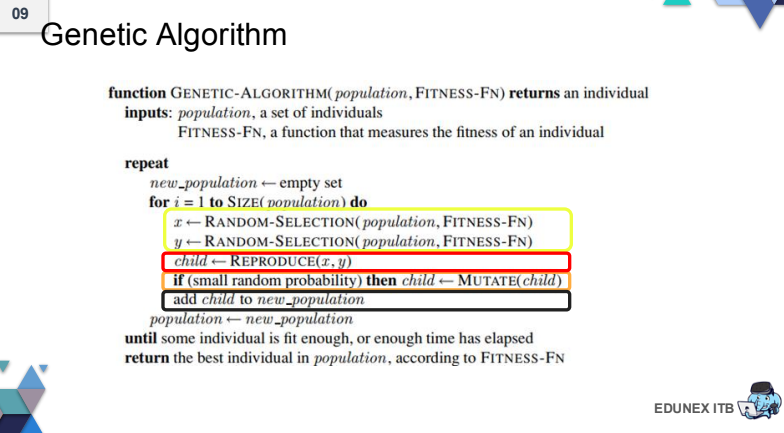

In [ ]:
import random
import copy
import math
import matplotlib.pyplot as plt
import numpy as np
import time


base_requests = [1, 2, 3, 4, 5, 1, 2, 3, 4, 5]


distance = [
    [7770, 6896, 9292,  661, 5776, 7770, 6896, 9292,  661, 5776],
    [1360, 9166, 8933, 4797, 2562, 1360, 9166, 8933, 4797, 2562],
    [5890, 9774, 8013, 1495,  564, 5890, 9774, 8013, 1495,  564],
    [5691, 3058, 3112, 8129, 8506, 5691, 3058, 3112, 8129, 8506],
    [6234, 8349, 7541, 9967, 3068, 6234, 8349, 7541, 9967, 3068],
    [6765, 2547, 6735, 1516, 5963, 6765, 2547, 6735, 1516, 5963],
    [ 966, 3247, 5986, 8369, 2527,  966, 3247, 5986, 8369, 2527],
    [4926, 9667, 7599, 6939, 3195, 4926, 9667, 7599, 6939, 3195],
    [6078,  689, 1275, 8392, 5758, 6078,  689, 1275, 8392, 5758],
    [8822, 3234, 8726, 7363, 6118, 8822, 3234, 8726, 7363, 6118],
    [2185, 3505, 3652, 8416, 7236, 2185, 3505, 3652, 8416, 7236],
    [1269, 5158, 2085, 9029,  891, 1269, 5158, 2085, 9029,  891],
    [7449, 2399, 4443, 1378, 6392, 7449, 2399, 4443, 1378, 6392],
    [2933, 8234, 8055, 9768, 4061, 2933, 8234, 8055, 9768, 4061],
    [5811, 1767, 3573, 5387, 6684, 5811, 1767, 3573, 5387, 6684],
    [5551, 2028, 1521, 5359, 3599, 5551, 2028, 1521, 5359, 3599],
    [7561, 3732,  528, 7075,  528, 7561, 3732,  528, 7075,  528],
    [7574, 5977, 8907,  858, 3393, 7574, 5977, 8907,  858, 3393],
    [9117,  102, 2261, 9443,  122, 9117,  102, 2261, 9443,  122],
    [ 801, 8643, 4722,  398, 5485,  801, 8643, 4722,  398, 5485],
]

duration = [
    [537, 199, 471, 838, 395, 537, 199, 471, 838, 395],
    [ 64, 269,  84,  91, 936,  64, 269,  84,  91, 936],
    [741, 807, 588, 796,  71, 741, 807, 588, 796,  71],
    [269,  68, 102, 985, 462, 269,  68, 102, 985, 462],
    [497, 395,  12, 404, 543, 497, 395,  12, 404, 543],
    [995, 385,  38, 996, 660, 995, 385,  38, 996, 660],
    [184, 803,  47, 134, 701, 184, 803,  47, 134, 701],
    [164, 317, 589, 816, 587, 164, 317, 589, 816, 587],
    [649, 636, 151, 395, 893, 649, 636, 151, 395, 893],
    [846,  29, 661, 100, 612, 846,  29, 661, 100, 612],
    [174, 913, 648, 882,  42, 174, 913, 648, 882,  42],
    [142, 404, 108, 625, 768, 142, 404, 108, 625, 768],
    [314, 181, 205, 757, 747, 314, 181, 205, 757, 747],
    [ 76, 703, 716, 898, 333,  76, 703, 716, 898, 333],
    [461, 587,  80,  33, 999, 461, 587,  80,  33, 999],
    [607, 127, 620,  47, 274, 607, 127, 620,  47, 274],
    [677, 205, 311,  81, 731, 677, 205, 311,  81, 731],
    [484, 991,  14, 187, 107, 484, 991,  14, 187, 107],
    [278, 733, 734, 762, 458, 278, 733, 734, 762, 458],
    [269,  85,  50, 893, 180, 269,  85,  50, 893, 180],
]

cum_order = [
    [3.75, 9.34, 6.22, 6.11, 1.01, 3.75, 9.34, 6.22, 6.11, 1.01],
    [9.54, 3.32, 4.06, 4.64, 3.19, 9.54, 3.32, 4.06, 4.64, 3.19],
    [0.36, 3.27, 2.68, 0.34, 0.50, 0.36, 3.27, 2.68, 0.34, 0.50],
    [4.14, 1.80, 2.70, 2.58, 3.42, 4.14, 1.80, 2.70, 2.58, 3.42],
    [3.24, 9.33, 2.17, 4.54, 7.87, 3.24, 9.33, 2.17, 4.54, 7.87],
    [1.39, 2.30, 8.43, 6.29, 1.13, 1.39, 2.30, 8.43, 6.29, 1.13],
    [4.34, 7.15, 3.79, 0.87, 5.05, 4.34, 7.15, 3.79, 0.87, 5.05],
    [9.41, 6.65, 4.07, 8.14, 5.86, 9.41, 6.65, 4.07, 8.14, 5.86],
    [2.46, 3.53, 2.90, 2.97, 4.48, 2.46, 3.53, 2.90, 2.97, 4.48],
    [8.97, 0.24, 9.37, 2.60, 8.02, 8.97, 0.24, 9.37, 2.60, 8.02],
    [1.18, 1.44, 9.76, 6.12, 3.23, 1.18, 1.44, 9.76, 6.12, 3.23],
    [1.42, 1.41, 9.32, 0.54, 2.47, 1.42, 1.41, 9.32, 0.54, 2.47],
    [0.27, 4.19, 0.68, 5.70, 6.18, 0.27, 4.19, 0.68, 5.70, 6.18],
    [4.90, 0.24, 1.13, 4.77, 7.14, 4.90, 0.24, 1.13, 4.77, 7.14],
    [6.26, 6.64, 2.57, 0.19, 4.24, 6.26, 6.64, 2.57, 0.19, 4.24],
    [1.71, 0.54, 6.12, 3.04, 4.12, 1.71, 0.54, 6.12, 3.04, 4.12],
    [7.07, 5.06, 3.26, 0.07, 0.08, 7.07, 5.06, 3.26, 0.07, 0.08],
    [7.60, 9.63, 9.11, 0.26, 8.72, 7.60, 9.63, 9.11, 0.26, 8.72],
    [4.67, 4.10, 9.04, 1.36, 4.38, 4.67, 4.10, 9.04, 1.36, 4.38],
    [1.46, 5.12, 5.58, 2.68, 6.25, 1.46, 5.12, 5.58, 2.68, 6.25],
]

base_order_rate = [26.0, 46.0, 10.0, 19.0, 47.0, 26.0, 46.0, 10.0, 17.0, 47.0]

taxis_battery = [100 for i in range(20)]

battery_treshold = 10

flat_duration = [item for row in duration for item in row]
min_duration = min(flat_duration)
max_duration = max(flat_duration)

flat_cumulative_order_rate = [item for row in cum_order for item in row]
min_cumulative_order_rate = min(flat_cumulative_order_rate)
max_cumulative_order_rate = max(flat_cumulative_order_rate)


min_base_order_rate = min(base_order_rate)
max_base_order_rate = max(base_order_rate)


alpha = 1
beta = 1
gamma = 1

def fitness_function(taxi_assignments):
    fitness = 0
    miu = 0.1
    
    for i in range(len(taxi_assignments)):
        assigned_base_request = taxi_assignments[i]
        if assigned_base_request is not None:
            order_rate_at_request_base = base_order_rate[assigned_base_request]
            cummulative_order_route = cum_order[i][assigned_base_request]
            estimated_duration= duration[i][assigned_base_request]

            d_hat = max((estimated_duration - min_duration), estimated_duration) / max((max_duration - min_duration), estimated_duration)
            cumulative_hat = 0 if(cummulative_order_route == 0) else max((cummulative_order_route - min_cumulative_order_rate), cummulative_order_route) / max((max_cumulative_order_rate - min_cumulative_order_rate), cummulative_order_route)
            base_order_rate_hat = max((order_rate_at_request_base - min_base_order_rate), order_rate_at_request_base) / max((max_base_order_rate - min_base_order_rate), order_rate_at_request_base)                                                                                
            fir = (alpha * (1- d_hat)) + (beta * (1 - cumulative_hat)) + (gamma * base_order_rate_hat)

            
            fitness_component = fir
            fitness += fitness_component
    
    return fitness

def is_valid_solution(solution):    
    assigned_requests = [req for req in solution if req is not None]
    if len(assigned_requests) != 10 or len(set(assigned_requests)) != 10:
        return False
    
    
    for i in range(len(solution)):
        assignment = solution[i]
        if assignment is not None:
            taxi_battery = taxis_battery[i]
            battery_consumption = 0.00024524 * distance[i][assignment] + 0 * duration[i][assignment]
            remaining_battery = taxi_battery - battery_consumption
            
            if remaining_battery < battery_treshold:
                return False
    
    return True

def generate_random_solution(max_attempts=1000):
    for _ in range(max_attempts):
        
        solution = [None] * 20
        
        
        taxis_to_assign = random.sample(range(20), 10)
        
        
        available_requests = list(range(10))
        random.shuffle(available_requests)
        
        for i, taxi_idx in enumerate(taxis_to_assign):
            solution[taxi_idx] = available_requests[i]
        
        if is_valid_solution(solution):
            return solution
    
    
    return None

def get_duplicate_element(individual):
    seen = set()
    duplicates = set()
    for item in individual:
        if item is not None:
            if item in seen:
                duplicates.add(item)
            else:
                seen.add(item)
    return list(duplicates)

def get_unassigned_request(parent, child):
    not_assigned = []
    for i in range(len(parent)):
        if parent[i] is not None and parent[i] not in child:
            not_assigned.append(parent[i])
    return not_assigned

def cycleCrossover(p1, p2):
    c1 = [None] * len(p1)
    c2 = [None] * len(p2)
    cycle = 0
    visited_indices = []
    
    for start_idx in range(0, len(p1)):
        if start_idx not in visited_indices:
            idx = start_idx
            cycle_indices = []
            while idx not in visited_indices:
                visited_indices.append(idx)
                cycle_indices.append(idx)
                
                try:
                    idx = p2.index(p1[idx])
                except ValueError:
                    break
            
            if cycle % 2 == 0:
                for i in cycle_indices:
                    if p1[i] is not None and p2[i] is not None:
                        if p1[i] not in c1 and p2[i] not in c2:
                            c1[i] = p1[i]
                            c2[i] = p2[i]
                        else:
                            c1[i] = p2[i]
                            c2[i] = p1[i]
                    elif p1[i] is not None:
                        c1[i] = p1[i]
                    elif p2[i] is not None:
                        c2[i] = p2[i]
            else:
                for i in cycle_indices:
                    if p1[i] is not None and p2[i] is not None:
                        if p2[i] not in c1 and p1[i] not in c2:
                            c1[i] = p2[i]
                            c2[i] = p1[i]
                        else:
                            c1[i] = p1[i]
                            c2[i] = p2[i]
                    elif p1[i] is not None:
                        c2[i] = p1[i]
                    elif p2[i] is not None:
                        c1[i] = p2[i]
            
            cycle += 1
    
    
    duplicate_c1 = get_duplicate_element(c1)
    duplicate_c2 = get_duplicate_element(c2)
    unassigned_c1 = get_unassigned_request(p1, c1)
    unassigned_c2 = get_unassigned_request(p2, c2)

    # cari duplikat, dan hapus
    for i in range(len(duplicate_c1)):
        duplicate_element = duplicate_c1[i]
        duplicate_idx = c1.index(duplicate_element)
        if len(unassigned_c1) > 0:
            c1[duplicate_idx] = unassigned_c1[0]
            unassigned_c1.remove(unassigned_c1[0])
        else:
            c1[duplicate_idx] = None
    
    # cari unassigned dan hapus
    for j in range(len(unassigned_c1)):
        unassigned_element = unassigned_c1[j]
        try:
            none_idx = c1.index(None)
            c1[none_idx] = unassigned_element
        except ValueError:  
            pass
    
    # cari duplikat, dan hapus
    for i in range(len(duplicate_c2)):
        duplicate_element = duplicate_c2[i]
        duplicate_idx = c2.index(duplicate_element)
        if len(unassigned_c2) > 0:
            c2[duplicate_idx] = unassigned_c2[0]
            unassigned_c2.remove(unassigned_c2[0])
        else:
            c2[duplicate_idx] = None
    
    # cari unassigned dan hapus
    for j in range(len(unassigned_c2)):
        unassigned_element = unassigned_c2[j]
        try:
            none_idx = c2.index(None)
            c2[none_idx] = unassigned_element
        except ValueError:
            pass
    
    return c1, c2

def mutate(solution, mutation_rate=0.1):
    if random.random() > mutation_rate:
        return solution  
    
    
    mutated = solution.copy()
    
    
    mutation_type = random.choice(["swap", "move", "add", "remove"])
    
    max_attempts = 50
    attempts = 0
    
    while attempts < max_attempts:
        if mutation_type == "swap":
            
            assigned_indices = [i for i, val in enumerate(mutated) if val is not None]
            if len(assigned_indices) >= 2:
                i, j = random.sample(assigned_indices, 2)
                mutated[i], mutated[j] = mutated[j], mutated[i]
        
        elif mutation_type == "move":
            
            assigned_indices = [i for i, val in enumerate(mutated) if val is not None]
            unassigned_indices = [i for i, val in enumerate(mutated) if val is None]
            
            if assigned_indices and unassigned_indices:
                from_idx = random.choice(assigned_indices)
                to_idx = random.choice(unassigned_indices)
                
                mutated[to_idx] = mutated[from_idx]
                mutated[from_idx] = None
        
        elif mutation_type == "add":
            
            unassigned_indices = [i for i, val in enumerate(mutated) if val is None]
            assigned_requests = [val for val in mutated if val is not None]
            unassigned_requests = [i for i in range(10) if i not in assigned_requests]
            
            if unassigned_indices and unassigned_requests:
                taxi_idx = random.choice(unassigned_indices)
                request = random.choice(unassigned_requests)
                mutated[taxi_idx] = request
        
        elif mutation_type == "remove":
            
            assigned_indices = [i for i, val in enumerate(mutated) if val is not None]
            
            if assigned_indices:
                taxi_idx = random.choice(assigned_indices)
                mutated[taxi_idx] = None
        
        
        if is_valid_solution(mutated):
            return mutated
        
        attempts += 1
    
    
    return solution

def random_selection(population, fitness_values):
    
    min_fitness = min(fitness_values)
    adjusted_fitness = [f - min_fitness + 1 if min_fitness < 0 else f + 1 for f in fitness_values]
    
    
    total_fitness = sum(adjusted_fitness)
    selection_probs = [f / total_fitness for f in adjusted_fitness]
    
    
    return random.choices(population, weights=selection_probs, k=1)[0]

def genetic_algorithm(population_size, num_of_cycle, crossover_trial, mutation_rate=0.1, max_attempts=1000):
    population = []
    for _ in range(population_size):
        solution = generate_random_solution(max_attempts)
        if solution is None:
            return None, None
        population.append(solution)
    
    
    fitness_values = [fitness_function(ind) for ind in population]
    
    
    best_idx = fitness_values.index(max(fitness_values))
    best_individual = population[best_idx]
    best_fitness = fitness_values[best_idx]
    
    
    for _ in range(num_of_cycle):
        new_population = []
        
        for _ in range(population_size):
            
            parent1 = random_selection(population, fitness_values)
            parent2 = random_selection(population, fitness_values)
            
            
            valid_child_found = False
            for _ in range(crossover_trial):
                child1, child2 = cycleCrossover(parent1, parent2)
                if is_valid_solution(child1) and is_valid_solution(child2):
                    
                    fitness1 = fitness_function(child1)
                    fitness2 = fitness_function(child2)
                    child = child1 if fitness1 > fitness2 else child2
                    valid_child_found = True
                    break
                elif is_valid_solution(child1):
                    child = child1
                    valid_child_found = True
                    break
                elif is_valid_solution(child2):
                    child = child2
                    valid_child_found = True
                    break
            
            
            if not valid_child_found:
                child = parent1 if fitness_function(parent1) > fitness_function(parent2) else parent2
            
            
            child = mutate(child, mutation_rate)
            
            
            new_population.append(child)
        
        
        population = new_population
        
        
        fitness_values = [fitness_function(ind) for ind in population]
        
        
        current_best_idx = fitness_values.index(max(fitness_values))
        current_best_fitness = fitness_values[current_best_idx]
        
        if current_best_fitness > best_fitness:
            best_individual = population[current_best_idx]
            best_fitness = current_best_fitness
    
    
    if not is_valid_solution(best_individual):
        return None, None
    
    return best_individual, best_fitness

def plot_distributions(population_size=50, num_of_cycle=100, crossover_trial=50, mutation_rate=0.1, runs=1000, max_attempts=1000):
    fitness_values = []
    duration_values = []
    valid_runs = 0
    
    
    for i in range(runs):
            
        start_time = time.time()
        
        solution, fitness = genetic_algorithm(
            population_size=population_size,
            num_of_cycle=num_of_cycle,
            crossover_trial=crossover_trial,
            mutation_rate=mutation_rate,
            max_attempts=max_attempts
        )
        
        end_time = time.time()
        duration = end_time - start_time
        duration_values.append(duration)
        
        if solution is not None and fitness is not None:
            fitness_values.append(fitness)
            valid_runs += 1
    

    
    if fitness_values:
        
        mean_fitness = np.mean(fitness_values)
        std_fitness = np.std(fitness_values)
        
        
        plt.figure(figsize=(8, 6))
        plt.hist(fitness_values, bins=20, edgecolor='black')
        plt.axvline(mean_fitness, linestyle='--', label=f'Mean = {mean_fitness:.2f}')
        plt.axvline(mean_fitness + std_fitness, color='gray', linestyle=':', 
                    label=f'Std = {std_fitness:.2f}')
        plt.title('Objective Function Score (Genetic Algorithm)')
        plt.xlabel('Fitness')
        plt.ylabel('Frequency')
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        print(f"Mean fitness: {mean_fitness:.4f}")
        print(f"Std deviation of fitness: {std_fitness:.4f}")
    else:
        mean_fitness = None
        std_fitness = None
        print("No valid solutions found")
    
    
    if duration_values:
        
        mean_duration = np.mean(duration_values)
        std_duration = np.std(duration_values)
        
        
        plt.figure(figsize=(8, 6))
        plt.hist(duration_values, bins=20, edgecolor='black')
        plt.axvline(mean_duration, linestyle='--', label=f'Mean = {mean_duration:.4f}s')
        plt.axvline(mean_duration + std_duration, color='gray', linestyle=':', 
                    label=f'Std = {std_duration:.4f}s')
        plt.title('Computation Time (Genetic Algorithm)')
        plt.xlabel('Time (seconds)')
        plt.ylabel('Frequency')
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        print(f"Mean computation time: {mean_duration:.4f} seconds")
        print(f"Std deviation of time: {std_duration:.4f} seconds")
    else:
        mean_duration = None
        std_duration = None
        print("No runs completed")
    
    return mean_fitness, std_fitness, mean_duration, std_duration

Running 1000 trials of Genetic Algorithm...
Completed 100 runs...
Completed 200 runs...
Completed 300 runs...
Completed 400 runs...
Completed 500 runs...
Completed 600 runs...
Completed 700 runs...
Completed 800 runs...
Completed 900 runs...
Valid solutions: 1000/1000 (100.00%)


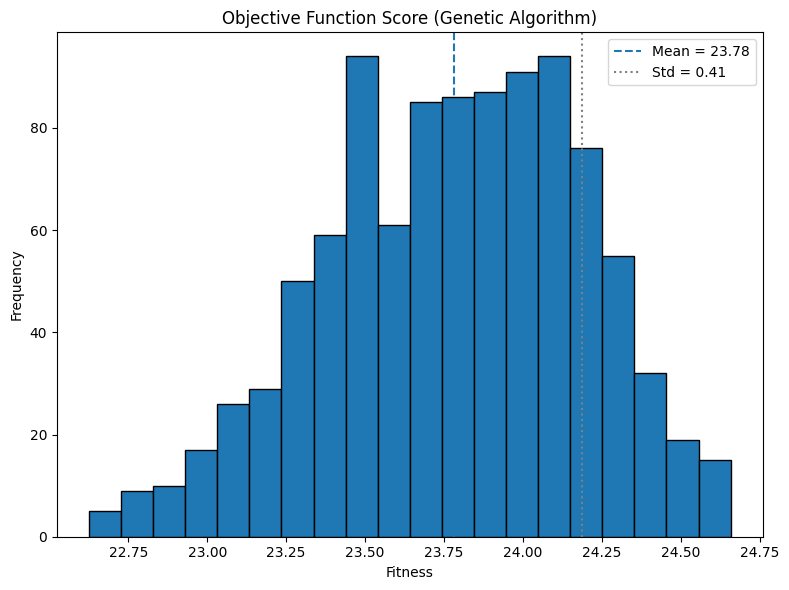

Mean fitness: 23.7814
Std deviation of fitness: 0.4059


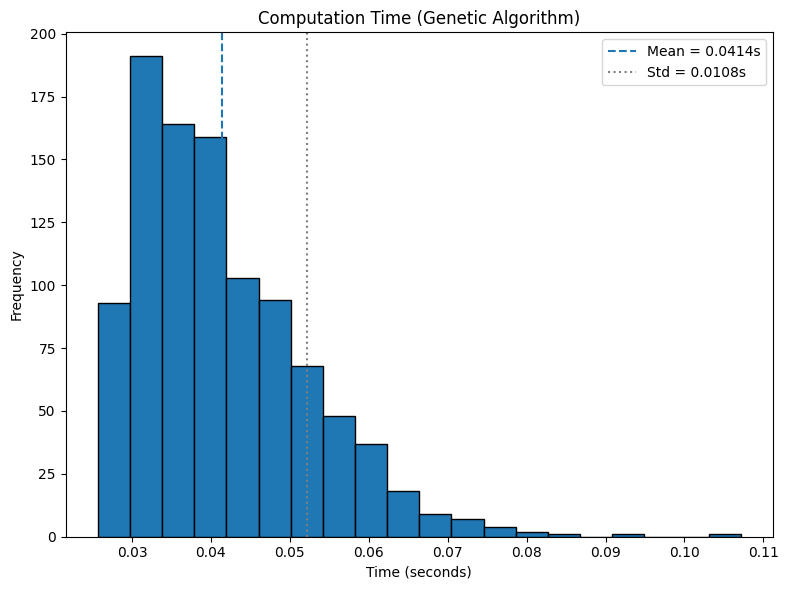

Mean computation time: 0.0414 seconds
Std deviation of time: 0.0108 seconds


In [4]:
mean_fitness, std_fitness, mean_duration, std_duration = plot_distributions(
        population_size=10,
        num_of_cycle=30,
        crossover_trial=10,
        mutation_rate=1,
        runs=1000,
        max_attempts=10
    )